Chromatic number: 3.0
Group: [3, 5, 7]
Group: [2, 4, 6, 10]
Group: [1, 8, 9]


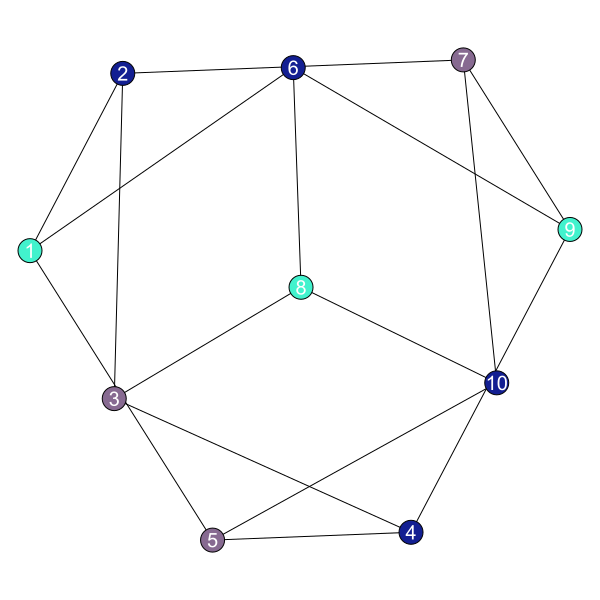

In [2]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 5 – Graph problems
#  Section: 5.4 – Graph Coloring Problem (GCP)
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP    # Modeling language
using HiGHS   # Solver
using Graphs  # Graphs package
using Karnak  # Graphs Visualization package
using Colors  # Colors package
using Random  # Random number generation

# Function to plot the solution
function plot_solution(graph, x, y)
    # Create color vector
    n = Graphs.nv(graph)
    
    # Create a vector of n different colors
    colors = [Colors.RGB(rand(), rand(), rand()) for _ in 1:n]

    # Add colors to vertices
    vertexfillcolors = [colors[c] for c in 1:n]
    for c in 1:n
        if JuMP.value(y[c]) >= 0.5
            ids = findall(JuMP.value.(x[:,c]) .>= 0.5)
            vertexfillcolors[ids] .= colors[c]
            println("Group: $ids")
        end
    end

    # Draw graph
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(20)
        drawgraph(
            graph,
            layout = stress,
            vertexshapesizes = 12,
            vertexlabels = 1:n,
            vertexfillcolors = vertexfillcolors
        )
    end
end

# Function to solve the Graph Coloring Problem (GCP)
function solve_gcp(graph)
    # Total of vertices
    n = Graphs.nv(graph)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:n], Bin)
    @variable(model, y[1:n], Bin)

    # Objective function: minimize the total of selected vertices
    @objective(model, Min, sum(y))

    # Each vertex must be assigned exactly one color
    @constraint(model, [u = 1:n], sum(x[u,:]) == 1)

    # No two adjacent vertices share the same color
    @constraint(model, [u = 1:n, v = 1:n, c = 1:n; Graphs.has_edge(graph, u, v)], x[u,c] + x[v,c] <= y[c])
    
    # Run the solver
    JuMP.optimize!(model)
    
    # Chromatic number
    Χ = JuMP.objective_value(model)

    # Print solution
    println("Chromatic number: $Χ")

    # Plot solution
    plot_solution(graph, x, y)
end

# Set random seed for generating colors
Random.seed!(15)

# Create graph
graph = Karnak.smallgraph("petersen")

# Solve the Graph Coloring Problem
solve_gcp(graph)